<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium

In [2]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=False)

In [4]:
state_size = env.observation_space.n
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))

print("Q-Table Shape:", q_table.shape)

Q-Table Shape: (16, 4)


In [5]:
learning_rate = 0.8
discount_factor = 0.95

episodes = 1000
max_steps = 100

epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.005

In [6]:
# Training Q-Learning Agent

rewards = []

for episode in range(episodes):

    state, _ = env.reset()

    total_rewards = 0

    for step in range(max_steps):

        # Exploration vs Exploitation
        exp_exp_tradeoff = random.uniform(0,1)

        if exp_exp_tradeoff > epsilon:

            action = np.argmax(q_table[state,:])

        else:

            action = env.action_space.sample()

        # Take Action
        new_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        # Update Q-Table
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward +
            discount_factor * np.max(q_table[new_state,:]) -
            q_table[state, action]
        )

        state = new_state

        total_rewards += reward

        if done:
            break

    # Reduce Exploration
    epsilon = min_epsilon + (
        max_epsilon - min_epsilon
    ) * np.exp(-decay_rate * episode)

    rewards.append(total_rewards)

In [7]:
print("\nTrained Q-Table:\n")

print(q_table)



Trained Q-Table:

[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.66342028 0.69833442]
 [0.69833729 0.         0.35899012 0.58546696]
 [0.47235542 0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.85737499 0.95       0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


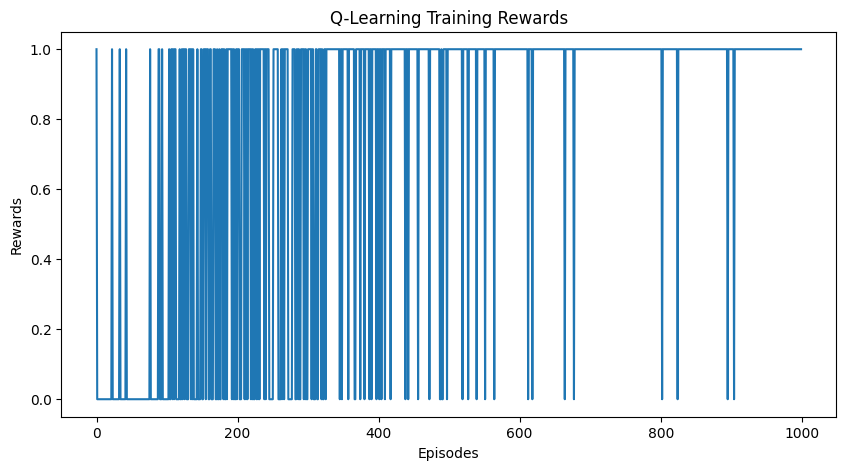

In [8]:

plt.figure(figsize=(10,5))

plt.plot(rewards)

plt.xlabel("Episodes")
plt.ylabel("Rewards")

plt.title("Q-Learning Training Rewards")

plt.show()

In [9]:
# Test the Agent

state, _ = env.reset()

done = False

print("\nTesting Agent...\n")

while not done:

    action = np.argmax(q_table[state,:])

    new_state, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

    print("State:", state, " Action:", action)

    state = new_state

if reward == 1:
    print("\nGoal Reached Successfully!")
else:
    print("\nAgent Failed!")


Testing Agent...

State: 0  Action: 1
State: 4  Action: 1
State: 8  Action: 2
State: 9  Action: 1
State: 13  Action: 2
State: 14  Action: 2

Goal Reached Successfully!
